In [1]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, roc_auc_score, confusion_matrix, RocCurveDisplay
from sklearn.model_selection import train_test_split
from torch_geometric.data import Data
from src.utils.config import PHYLO_DIST_MATRIX, LABELS_RM_METABOLITES, SIMPLE_GNN_XP_RESULTS, MODEL_CONFIGS_DIR
from src.models.SimpleGNN import SimpleGNN
import yaml

device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: mps


/Users/encordsf/Desktop/phylo-gnn/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Select run to evaluate
Copy the best `run_name` from TensorBoard HParams tab (sorted by `auroc_macro`) into the cell below.

In [2]:
import os

# Describe the best config — used to find matching seed run folders
# (no timestamp needed — we scan the results dir instead)
BEST_CONFIG_TAG = "k10-h64-lr0.01-l3-dp0.3"   # <-- update from TensorBoard HParams tab

seed_runs = sorted([
    d for d in os.listdir(SIMPLE_GNN_XP_RESULTS)
    if BEST_CONFIG_TAG in d and "-seed" in d
])
print(f"Found {len(seed_runs)} seed runs:")
for r in seed_runs:
    print(f"  {r}")

Found 3 seed runs:
  2026-03-12_1558-k10-h64-lr0.01-l3-dp0.3-seed0
  2026-03-12_1558-k10-h64-lr0.01-l3-dp0.3-seed1
  2026-03-12_1558-k10-h64-lr0.01-l3-dp0.3-seed2


## Rebuild graph
Identical setup to the train notebook — same splits, same masks, same edge weights.
The **test_mask nodes were never seen during training** (their features were zeroed out).

In [3]:
from collections import Counter

with open(MODEL_CONFIGS_DIR / 'SimpleGNN' / 'default.yaml') as f:
    cfg = yaml.safe_load(f)

labels      = pd.read_csv(LABELS_RM_METABOLITES)
dist_matrix = np.load(PHYLO_DIST_MATRIX)
metabolite_columns = ['b12', 'heme', 'folate', 'biotin']

# Rebuild edges (must use same k as training run)
k = cfg['k']
def get_knn_edges(matrix, k):
    edges, distances = [], []
    for i in range(len(matrix)):
        top_k = np.argsort(matrix[i])[1:k+1]
        for j in top_k:
            edges.append([i, j])
            distances.append(matrix[i][j])
    return edges, distances

edges, distances = get_knn_edges(dist_matrix, k)
edges_tensor = torch.tensor(np.array(edges).T)

x = torch.tensor(labels[metabolite_columns].values, dtype=torch.float)
y = x.clone()
data = Data(x=x, edge_index=edges_tensor, y=y)

# Same split as training (same random_state)
indices = np.arange(len(labels))
train_idx, temp  = train_test_split(indices, test_size=0.4, random_state=19)
val_idx, test_idx = train_test_split(temp,   test_size=0.5, random_state=19)

train_mask = torch.zeros(data.num_nodes, dtype=torch.bool)
val_mask   = torch.zeros(data.num_nodes, dtype=torch.bool)
test_mask  = torch.zeros(data.num_nodes, dtype=torch.bool)
train_mask[train_idx] = True
val_mask[val_idx]     = True
test_mask[test_idx]   = True

# Zero out val+test features (same as training)
data.x[val_mask | test_mask] = 0

data.x          = data.x.to(device)
data.y          = data.y.to(device)
data.edge_index = data.edge_index.to(device)
test_mask       = test_mask.to(device)

if cfg['edge_weight']:
    data.edge_weight = torch.tensor([1/d for d in distances], dtype=torch.float).to(device)
else:
    data.edge_weight = None

print(f'Test nodes: {test_mask.sum().item()}')

Test nodes: 940


## Evaluate on test set
Your turn — implement `evaluate_test` below.

In [4]:
def evaluate_test(model, data, mask, metabolite_columns):
    model.eval()
    with torch.no_grad():
        out   = model(data.x, data.edge_index, data.edge_weight)
        probs = torch.sigmoid(out[mask]).cpu().numpy()
        preds = (probs > 0.5).astype(int)
        true  = data.y[mask].cpu().numpy().astype(int)

    results = {}
    for i, trait in enumerate(metabolite_columns):
        results[trait] = {
            'f1':    f1_score(true[:, i], preds[:, i], zero_division=0),
            'auroc': roc_auc_score(true[:, i], probs[:, i]),
        }
    macro_auroc = np.mean([v['auroc'] for v in results.values()])
    macro_f1    = np.mean([v['f1']    for v in results.values()])
    results['macro'] = {'f1': macro_f1, 'auroc': macro_auroc}
    return results


all_results = {}

for run_name in seed_runs:
    ckpt = SIMPLE_GNN_XP_RESULTS / run_name / "model.pt"
    print(f"\n{run_name}")

    model = SimpleGNN(
        input_dim  = cfg['input_dim'],
        hidden_dim = cfg['hidden_dim'],
        output_dim = cfg['output_dim'],
        num_layers = cfg['num_layers'],
        p_dropout  = cfg['p_dropout'],
    ).to(device)
    model.load_state_dict(torch.load(ckpt, map_location=device))

    results = evaluate_test(model, data, test_mask, metabolite_columns)
    all_results[run_name] = results

    pd.DataFrame(results).T.to_csv(SIMPLE_GNN_XP_RESULTS / run_name / "test_results.csv")

    print(f"{'Trait':<10} {'F1':>6} {'AUROC':>7}")
    print("-" * 26)
    for trait, metrics in results.items():
        print(f"{trait:<10} {metrics['f1']:>6.3f} {metrics['auroc']:>7.3f}")


2026-03-12_1558-k10-h64-lr0.01-l3-dp0.3-seed0
Trait          F1   AUROC
--------------------------
b12         0.764   0.905
heme        0.851   0.961
folate      0.822   0.926
biotin      0.807   0.959
macro       0.811   0.937

2026-03-12_1558-k10-h64-lr0.01-l3-dp0.3-seed1
Trait          F1   AUROC
--------------------------
b12         0.770   0.905
heme        0.857   0.964
folate      0.829   0.926
biotin      0.818   0.959
macro       0.819   0.939

2026-03-12_1558-k10-h64-lr0.01-l3-dp0.3-seed2
Trait          F1   AUROC
--------------------------
b12         0.762   0.904
heme        0.847   0.964
folate      0.821   0.925
biotin      0.816   0.959
macro       0.811   0.938


In [5]:
# Mean ± std across seeds — this is the number you report as the SimpleGNN baseline
traits = metabolite_columns + ['macro']

print(f"\n{'Trait':<10} {'AUROC mean':>12} {'AUROC std':>10} {'F1 mean':>9} {'F1 std':>8}")
print("-" * 55)
for trait in traits:
    aurocs = [all_results[r][trait]['auroc'] for r in seed_runs]
    f1s    = [all_results[r][trait]['f1']    for r in seed_runs]
    print(f"{trait:<10} {np.mean(aurocs):>12.3f} {np.std(aurocs):>10.3f} {np.mean(f1s):>9.3f} {np.std(f1s):>8.3f}")


Trait        AUROC mean  AUROC std   F1 mean   F1 std
-------------------------------------------------------
b12               0.905      0.001     0.765    0.003
heme              0.963      0.002     0.852    0.004
folate            0.926      0.000     0.824    0.003
biotin            0.959      0.000     0.813    0.005
macro             0.938      0.000     0.814    0.003


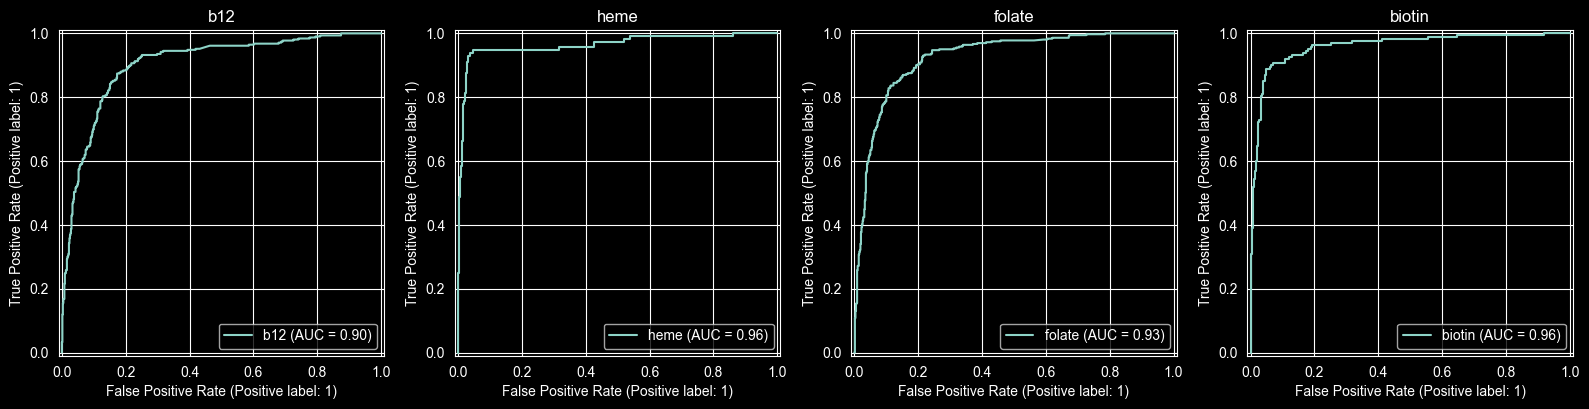

In [6]:
# ROC curves — one per trait
with torch.no_grad():
    out   = model(data.x, data.edge_index, data.edge_weight)
    probs = torch.sigmoid(out[test_mask]).cpu().numpy()
    true  = data.y[test_mask].cpu().numpy().astype(int)

fig, axes = plt.subplots(1, len(metabolite_columns), figsize=(16, 4))
for i, (trait, ax) in enumerate(zip(metabolite_columns, axes)):
    RocCurveDisplay.from_predictions(true[:, i], probs[:, i], ax=ax, name=trait)
    ax.set_title(trait)
plt.tight_layout()
plt.show()